In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

### Importing Data

In [2]:
df = pd.read_excel("data/Data_FE.xlsx", sheet_name="25 Size and BEME portfolios")
df.head()

,Unnamed: 0,Average,Value,Weighted,Returns,--,Monthly,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,Size,Small,Small,Small,Small,Small,2,2.00,2.00,2.00,...,4,4.00,4.00,4.00,4,Big,Big,Big,Big,Big
1,BE/ME,Low,2,3,4,High,Low,2.00,3.00,4.00,...,Low,2.00,3.00,4.00,High,Low,2,3,4,High
2,193601,26.94,15.49,21.82,14.56,33.28,16.43,12.49,9.49,10.27,...,2.13,6.87,8.92,8.35,6.17,2.55,6.36,8.62,14.84,16.29
3,193602,9.46,12.78,6.77,10.02,9,1.7,6.71,5.61,8.92,...,2.59,4.04,6.14,4.80,8.43,1.88,1.18,3.99,3.38,3.75
4,193603,9.46,1.38,5.56,3.01,1.24,-0.37,1.35,3.33,-1.11,...,-0.46,-0.40,3.19,1.52,-4.36,3.58,1.27,-1.82,1.26,-3.56


In [3]:
# Set rows 1 and 2 as MultiIndex header
df.columns = pd.MultiIndex.from_arrays([df.iloc[0], df.iloc[1]])
df = df.iloc[2:].reset_index(drop=True)

# Convert Date column to Year-Month
date_col = df.columns[0]

df[date_col] = pd.to_datetime(df[date_col].astype(int), format="%Y%m")

df = df.set_index(df.columns[0]) 
df = df.apply(pd.to_numeric)

df.head()

0              Small                                  2                       \
1                Low      2      3      4   High    Low      2      3      4   
(Size, BE/ME)                                                                  
1936-01-01     26.94  15.49  21.82  14.56  33.28  16.43  12.49   9.49  10.27   
1936-02-01      9.46  12.78   6.77  10.02   9.00   1.70   6.71   5.61   8.92   
1936-03-01      9.46   1.38   5.56   3.01   1.24  -0.37   1.35   3.33  -1.11   
1936-04-01    -28.60 -29.05 -12.37 -14.03 -21.72 -19.41 -13.35 -15.93 -16.43   
1936-05-01      1.81   8.62   1.89  10.60   5.90   5.21   4.59   7.57   5.84   

0                     ...     4                              Big              \
1               High  ...   Low     2      3      4   High   Low     2     3   
(Size, BE/ME)         ...                                                      
1936-01-01     26.81  ...  2.13  6.87   8.92   8.35   6.17  2.55  6.36  8.62   
1936-02-01      3.87  ...  2.59  4.04   6.14   4.80   8.43  1.88  1.18  3.99   
1936-03-01      1.25  ... -0.46 -0.40   3.19   1.52  -4.36  3.58  1.27 -1.82   
1936-04-01    -17.69  ... -8.31 -9.00 -11.90 -12.09 -12.46 -6.17 -8.26 -7.05   
1936-05-01      6.97  ...  5.12  1.79   4.54   5.98   8.18  4.78  5.20  4.71   

0                            
1                  4   High  
(Size, BE/ME)                
1936-01-01     14.84  16.29  
1936-02-01      3.38   3.75  
1936-03-01      1.26  -3.56  
1936-04-01    -10.57  -8.00  
1936-05-01      6.25   8.39  

[5 rows x 25 columns]

In [4]:
macro_factors = pd.read_excel("data/Data_FE.xlsx", sheet_name="Macroeconomic factors")

# Convert Date column to Year-Month
date_col = macro_factors.columns[0] 

macro_factors[date_col] = pd.to_datetime(macro_factors[date_col].astype(int), format="%Y%m")
factors = macro_factors.set_index(macro_factors.columns[0]) 
factors = factors.apply(pd.to_numeric)

macro_factors.head()

,Date,Div_growth,DEF = LT Corp. - LT govt.,TERM = ST govt.-LT govt.
0,1936-01-01,0.001990,0.002660,0.005395
1,1936-02-01,0.003113,-0.002690,0.007990
2,1936-03-01,0.003308,-0.002406,0.010458
3,1936-04-01,0.001250,-0.000924,0.003359
4,1936-05-01,0.004499,-0.000049,0.003887


In [5]:
excess_returns = df.copy()

factors = factors.reindex(excess_returns.index)

excess_returns = excess_returns.sub(factors["TERM = ST govt.-LT govt."], axis=0)
excess_returns.head()

0                  Small                                              \
1                    Low          2          3          4       High   
(Size, BE/ME)                                                          
1936-01-01     26.934605  15.484605  21.814605  14.554605  33.274605   
1936-02-01      9.452010  12.772010   6.762010  10.012010   8.992010   
1936-03-01      9.449542   1.369542   5.549542   2.999542   1.229542   
1936-04-01    -28.603359 -29.053359 -12.373359 -14.033359 -21.723359   
1936-05-01      1.806113   8.616113   1.886113  10.596113   5.896113   

0                      2                                              ...  \
1                    Low          2          3          4       High  ...   
(Size, BE/ME)                                                         ...   
1936-01-01     16.424605  12.484605   9.484605  10.264605  26.804605  ...   
1936-02-01      1.692010   6.702010   5.602010   8.912010   3.862010  ...   
1936-03-01     -0.380458   1.339542   3.319542  -1.120458   1.239542  ...   
1936-04-01    -19.413359 -13.353359 -15.933359 -16.433359 -17.693359  ...   
1936-05-01      5.206113   4.586113   7.566113   5.836113   6.966113  ...   

0                     4                                                  Big  \
1                   Low         2          3          4       High       Low   
(Size, BE/ME)                                                                  
1936-01-01     2.124605  6.864605   8.914605   8.344605   6.164605  2.544605   
1936-02-01     2.582010  4.032010   6.132010   4.792010   8.422010  1.872010   
1936-03-01    -0.470458 -0.410458   3.179542   1.509542  -4.370458  3.569542   
1936-04-01    -8.313359 -9.003359 -11.903359 -12.093359 -12.463359 -6.173359   
1936-05-01     5.116113  1.786113   4.536113   5.976113   8.176113  4.776113   

0                                                        
1                     2         3          4       High  
(Size, BE/ME)                                            
1936-01-01     6.354605  8.614605  14.834605  16.284605  
1936-02-01     1.172010  3.982010   3.372010   3.742010  
1936-03-01     1.259542 -1.830458   1.249542  -3.570458  
1936-04-01    -8.263359 -7.053359 -10.573359  -8.003359  
1936-05-01     5.196113  4.706113   6.246113   8.386113  

[5 rows x 25 columns]

## In-Sample Principal Component Factors

### Covariance Matrix

<Axes: xlabel='0-1', ylabel='0-1'>

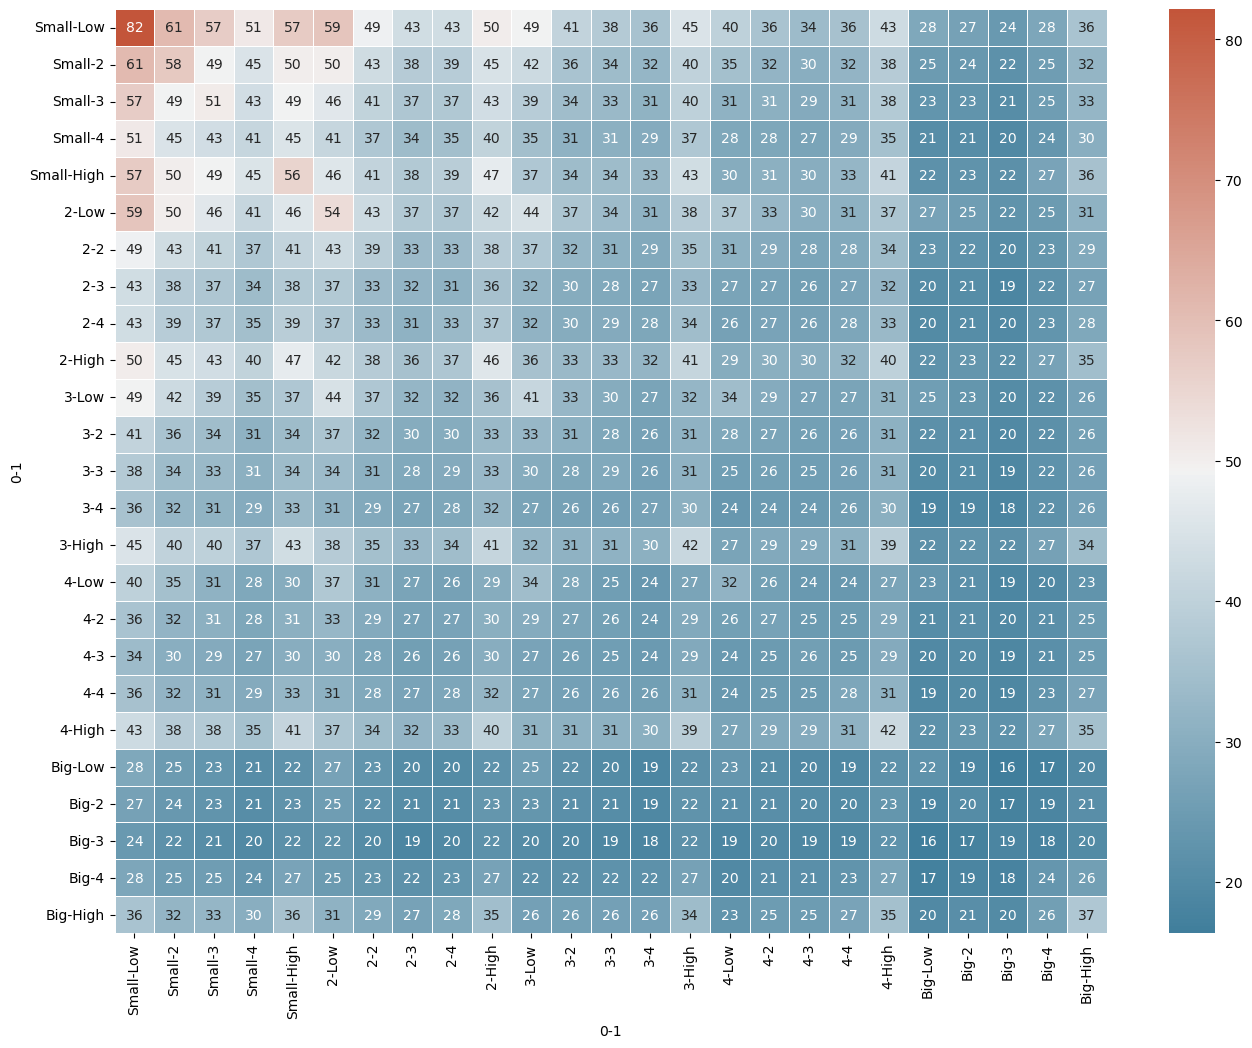

In [6]:
cova_matrix = excess_returns.cov()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(16, 12))

# a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(cova_matrix, cmap=cmap,  annot=True, linewidth=.5)

### Eigen Vectors and Values

In [7]:
# Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cova_matrix)

# eigh returns in ASCENDING order — reverse to get largest first
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]    # 25 × 25, columns are eigenvectors

# extracting 3 largest eigenvectors, the factor weights is 25 x 3
W = eigenvectors[:, :3]

# factor time-series (T x 3)
F = excess_returns.values @ W 

in_sample_factors_df = pd.DataFrame(F, index=excess_returns.index, columns=['PC1', 'PC2', 'PC3'])

in_sample_factors_df.head()

,PC1,PC2,PC3
"(Size, BE/ME)",,,
1936-01-01,68.032285,-8.331803,20.995633
1936-02-01,27.507629,-1.799596,7.564300
1936-03-01,8.558362,-6.086865,-1.359546
1936-04-01,-70.181755,11.244138,-4.735477
1936-05-01,27.877746,7.509749,4.294490


In [8]:
print(eigenvalues)
# print(eigenvectors)

[792.3787783   45.10873558  32.77232973  11.15720386   7.41946603
   6.15190209   4.93700895   4.12917163   3.79956685   3.1181925
   2.77449298   2.57211037   2.3319981    2.13632479   2.02809018
   2.00871327   1.62867904   1.60522846   1.46593993   1.37362689
   1.32120777   1.2785196    1.24336541   1.14043336   1.04594963]


In [9]:
total_var = eigenvalues.sum()
print(eigenvalues[:3] / total_var)

[0.8457209  0.04814541 0.03497853]


## Out-Sample Principle Component Factors

In [12]:
# Dummy excess returns dataframe
odd_returns_df = excess_returns.copy()

# Removing Even Month returns
odd_returns_df = odd_returns_df.iloc[0::2]

odd_returns_df.head()

0                  Small                                              \
1                    Low          2          3          4       High   
(Size, BE/ME)                                                          
1936-01-01     26.934605  15.484605  21.814605  14.554605  33.274605   
1936-03-01      9.449542   1.369542   5.549542   2.999542   1.229542   
1936-05-01      1.806113   8.616113   1.886113  10.596113   5.896113   
1936-07-01      2.404132   1.894132  15.384132  11.054132   7.294132   
1936-09-01     -3.496781   2.353219  -0.106781   7.613219   5.173219   

0                      2                                             ...  \
1                    Low          2         3          4       High  ...   
(Size, BE/ME)                                                        ...   
1936-01-01     16.424605  12.484605  9.484605  10.264605  26.804605  ...   
1936-03-01     -0.380458   1.339542  3.319542  -1.120458   1.239542  ...   
1936-05-01      5.206113   4.586113  7.566113   5.836113   6.966113  ...   
1936-07-01     10.794132  13.494132  8.814132   7.284132   4.674132  ...   
1936-09-01      5.313219   4.673219  4.663219   2.363219   2.773219  ...   

0                     4                                                Big  \
1                   Low         2         3         4       High       Low   
(Size, BE/ME)                                                                
1936-01-01     2.124605  6.864605  8.914605  8.344605   6.164605  2.544605   
1936-03-01    -0.470458 -0.410458  3.179542  1.509542  -4.370458  3.569542   
1936-05-01     5.116113  1.786113  4.536113  5.976113   8.176113  4.776113   
1936-07-01     8.024132  4.894132  8.424132  8.424132  12.604132  5.714132   
1936-09-01     1.743219  2.753219  1.313219  2.423219   4.183219  1.223219   

0                                                        
1                     2         3          4       High  
(Size, BE/ME)                                            
1936-01-01     6.354605  8.614605  14.834605  16.284605  
1936-03-01     1.259542 -1.830458   1.249542  -3.570458  
1936-05-01     5.196113  4.706113   6.246113   8.386113  
1936-07-01     5.364132  5.734132  11.484132  10.024132  
1936-09-01     0.563219  1.133219   1.083219  -0.546781  

[5 rows x 25 columns]

### Covariance Matrix

<Axes: xlabel='0-1', ylabel='0-1'>

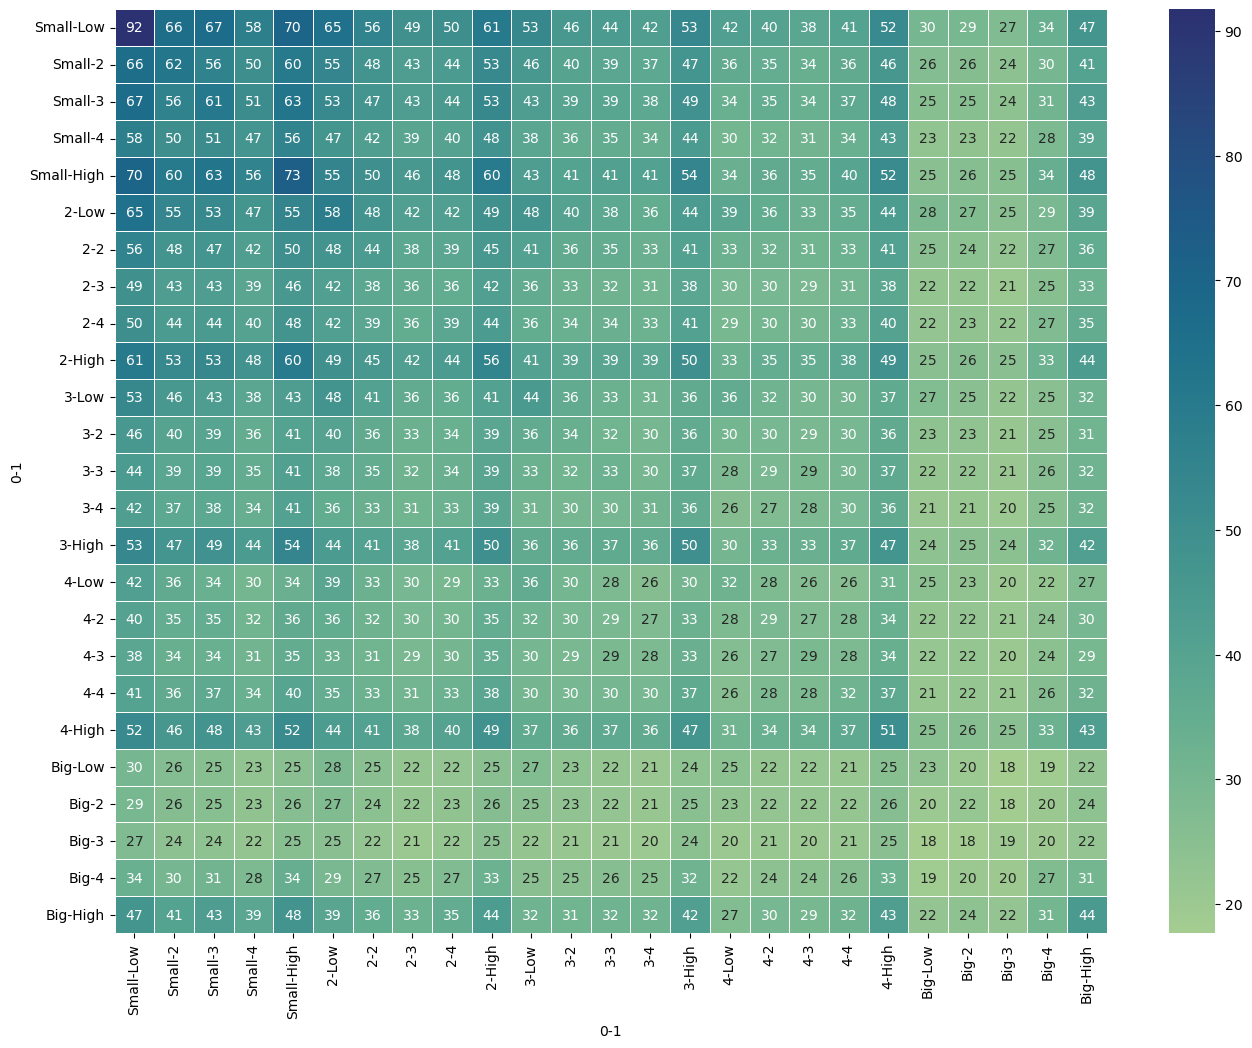

In [15]:
cova_matrix = odd_returns_df.cov()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(cova_matrix, cmap="crest",  annot=True, linewidth=.5)